<a href="https://colab.research.google.com/github/diegogr98/Diego-Gutierrez-Astronomy/blob/main/General_Relativity_KerrMetric.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -Uq einsteinpy pymcel

In [ ]:
import pymcel as pc
import einsteinpy.symbolic as es
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from scipy.integrate import solve_ivp
from matplotlib.patches import Circle

In [ ]:
# Coordenadas de Boyer–Lindquist
t, r, theta, phi = sp.symbols('t r theta phi', real=True)

# Parámetros físicos:
s, a, c = sp.symbols('s a c', real=True)

# Cantidades auxiliares
Sigma = r**2 + (a*s)**2 * sp.cos(theta)**2
Delta = r**2 - 2*s*r + (a*s)**2

# Construcción de la métrica de Kerr en coordenadas Boyer–Lindquist
g = sp.zeros(4)

# g_tt
g[0, 0] = (1 - 2*s*r / Sigma) * c**2

# g_tφ = g_φt
g_tphi = (2 * a * c * s**2 * r * sp.sin(theta)**2) / Sigma
g[0, 3] = g_tphi
g[3, 0] = g_tphi

# g_rr
g[1, 1] = -Sigma / Delta

# g_θθ
g[2, 2] = -Sigma

# g_φφ
g[3, 3] = - (sp.sin(theta)**2 / Sigma) * (
    (r**2 + (a*s)**2)**2 - (a*s)**2 * Delta * sp.sin(theta)**2
)
g

Matrix([
[         c**2*(-2*r*s/(a**2*s**2*cos(theta)**2 + r**2) + 1),                                                            0,                               0,                                                                   2*a*c*r*s**2*sin(theta)**2/(a**2*s**2*cos(theta)**2 + r**2)],
[                                                          0, (-a**2*s**2*cos(theta)**2 - r**2)/(a**2*s**2 + r**2 - 2*r*s),                               0,                                                                                                                             0],
[                                                          0,                                                            0, -a**2*s**2*cos(theta)**2 - r**2,                                                                                                                             0],
[2*a*c*r*s**2*sin(theta)**2/(a**2*s**2*cos(theta)**2 + r**2),                                                            0,             


Para estudiar el límite en el que desaparece el momento angular del agujero negro,
consideramos la métrica de Kerr en coordenadas de Boyer-Lindquist y hacemos
$a \to 0$. Al anular el parámetro $a$, que representa el momento angular por unidad
de masa, los términos que acoplan las coordenadas $t$ y $\phi$ desaparecen y las
funciones auxiliares se reducen a
$$
\Sigma \xrightarrow[a\to 0]{} r^{2},
\qquad
\Delta \xrightarrow[a\to 0]{} r^{2} - 2 s r.
$$

In [ ]:
# Métrica de kerr con a=0
g_a0 = g.subs(a, 0).applyfunc(sp.simplify)
g_a0

Matrix([
[c**2*(r - 2*s)/r,            0,     0,                   0],
[               0, -r/(r - 2*s),     0,                   0],
[               0,            0, -r**2,                   0],
[               0,            0,     0, -r**2*sin(theta)**2]])

Sustituyendo $a=0$ en la métrica de Kerr, esta adopta la forma

<br>

$$
ds^{2} =
\left(1 - \frac{2 s}{r}\right)c^{2}\,dt^{2}
- \left(1 - \frac{2 s}{r}\right)^{-1} dr^{2}
- r^{2}\, d\theta^{2}
- r^{2}\sin^{2}\theta\, d\phi^{2},
$$


que corresponde exactamente a la **métrica de Schwarzschild**. Esto demuestra
que la solución de Kerr se reduce a la solución esféricamente simétrica de
Schwarzschild cuando el momento angular es nulo.

 El procedimiento consiste en expandir cada componente $ g_{\mu\nu}(a) $ en serie de Taylor alrededor de $ a = 0 $ y conservar únicamente los términos hasta orden lineal.

Cada componente de la métrica se desarrolla como:

<br>

$$
g_{\mu\nu}(a)
= g_{\mu\nu}(0)
+ a\, \left.\frac{\partial g_{\mu\nu}}{\partial a}\right|_{a=0}
+ \mathcal{O}(a^2).
$$


Descartamos los términos de orden $ \mathcal{O}(a^2) $, obteniendo la métrica linealizada:

<br>

$$
g^{(1)}_{\mu\nu}
= g_{\mu\nu}(0)
+ a\, g'_{\mu\nu}(0).
$$

<br>

Las funciones auxiliares de la métrica de Kerr son:

<br>

  $$
\Sigma=r^2+(a s)^2 \cos ^2 \theta, \quad \Delta=r^2-2 s r+(a s)^2
$$

Dado que los términos proporcionales a $ a^{2} $ son de orden superior al considerado, las aproximamos por:

<br>

$$
\Sigma \approx r^{2}, \qquad
\Delta \approx r^{2} - 2sr.
$$

Estas sustituciones se aplican componente por componente después de la expansión en serie.

La métrica obtenida es:
$$
g^{(1)}_{\mu\nu}
= g_{\mu\nu}^{\text{Schwarzschild}}
+ \mathcal{O}(a),
$$

<br>

lo que muestra que la métrica linealizada consiste en la métrica de Schwarzschild más las correcciones de primer orden debidas al momento angular.


In [ ]:
# Expandimos cada componente de la métrica de Kerr y tomamos serie en a
g_l = sp.zeros(4)

for i in range(4):
    for j in range(4):
        gij = g[i, j]

        # Serie de Taylor alrededor de a=0
        gij_series = sp.series(gij, a, 0, 2).removeO()

        # Esto contiene término constante + término lineal en a
        gij_linear = gij_series.expand()

        g_l[i, j] = gij_linear

# Sustituimos aproximaciones Sigma -> r^2 y Δ -> r^2 - 2sr
Sigma_lin = r**2
Delta_lin = r**2 - 2*s*r

# Sustitución directa de las aproximaciones
subs_dict = {
    r**2 + (a*s)**2 * sp.cos(theta)**2: Sigma_lin,
    r**2 - 2*s*r + (a*s)**2: Delta_lin
}

# Aplicando las sustituciones y aproximando linealmente
g_l = g_l.subs(subs_dict).applyfunc(sp.simplify)

g_l

Matrix([
[          c**2*(r - 2*s)/r,            0,     0, 2*a*c*s**2*sin(theta)**2/r],
[                         0, -r/(r - 2*s),     0,                          0],
[                         0,            0, -r**2,                          0],
[2*a*c*s**2*sin(theta)**2/r,            0,     0,        -r**2*sin(theta)**2]])

En particular, el único término nuevo que sobrevive al orden lineal es el término cruzado $t\phi$:

<br>

$$
g^{(1)}_{t\phi}
=  \frac{2 a c s^2 \sin^{2}\theta}{r^{2}}.
$$

Esta métrica linealizada es la que se emplea para verificar que satisface las ecuaciones de campo métrico o paralelamente:

<br>

$$
R_{\mu\nu} = 0
$$
<br>

hasta orden $a$, y sirve para estudiar el efecto de rotación lenta sobre el movimiento de partículas.

In [ ]:
# Función de truncado a orden lineal en a
def trunc_lineal(expr, a):
    series = sp.series(expr, a, 0, 2).removeO()
    return sp.simplify(series)

# Convertir g_l a Array para einsteinpy
g_l_array = sp.Array(g_l.tolist())

# Calcular tensor de Ricci
metric_l = es.MetricTensor(g_l_array, (t, r, theta, phi))
Ricci_l = es.RicciTensor.from_metric(metric_l)

# Aplicar truncamiento a cada componente del tensor de Ricci
Ricci_lineal = Ricci_l.tensor().applyfunc(lambda x: trunc_lineal(x, a))

Ricci_lineal

[[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]

In [ ]:
# Calculando los simbolos de Christoffel simbolicamente
metric_lin = es.MetricTensor(sp.Array(g_l), [t, r, theta, phi])
G_lin = es.ChristoffelSymbols.from_metric(metric_lin)

coords = ['t','r','θ','φ']
Gamma = G_lin.tensor()

Gamma

[[[0, -2*a**2*c*s**4*sin(theta)**2/(r*(4*a**2*c*s**4*sin(theta)**2 + c*r**4 - 2*c*r**3*s)) + r**4*(c**2/r - c**2*(r - 2*s)/r**2)/(2*(4*a**2*c**2*s**4*sin(theta)**2 + c**2*r**4 - 2*c**2*r**3*s)), 4*a**2*c*s**4*sin(theta)*cos(theta)/(4*a**2*c*s**4*sin(theta)**2 + c*r**4 - 2*c*r**3*s), 0], [-2*a**2*c*s**4*sin(theta)**2/(r*(4*a**2*c*s**4*sin(theta)**2 + c*r**4 - 2*c*r**3*s)) + r**4*(c**2/r - c**2*(r - 2*s)/r**2)/(2*(4*a**2*c**2*s**4*sin(theta)**2 + c**2*r**4 - 2*c**2*r**3*s)), 0, 0, -a*c*r**2*s**2*sin(theta)**2/(4*a**2*c**2*s**4*sin(theta)**2 + c**2*r**4 - 2*c**2*r**3*s) - 2*a*r**2*s**2*sin(theta)**2/(4*a**2*c*s**4*sin(theta)**2 + c*r**4 - 2*c*r**3*s)], [4*a**2*c*s**4*sin(theta)*cos(theta)/(4*a**2*c*s**4*sin(theta)**2 + c*r**4 - 2*c*r**3*s), 0, 0, 2*a*c*r**3*s**2*sin(theta)*cos(theta)/(4*a**2*c**2*s**4*sin(theta)**2 + c**2*r**4 - 2*c**2*r**3*s) - 2*a*r**3*s**2*sin(theta)*cos(theta)/(4*a**2*c*s**4*sin(theta)**2 + c*r**4 - 2*c*r**3*s)], [0, -a*c*r**2*s**2*sin(theta)**2/(4*a**2*c**2*s**4*sin(

In [ ]:
# Creando las funciones numéricas a partir de las simbolicas
Gamma_num = [[[None]*4 for _ in range(4)] for __ in range(4)]

for mu in range(4):
    for a1 in range(4):
        for a2 in range(4):
            Gamma_num[mu][a1][a2] = sp.lambdify(
                (r, theta, s, a, c),
                sp.simplify(Gamma[mu,a1,a2]),
                "numpy"
            )

In [ ]:
# Definiendo la ecuacion de movimiento
def edm_kerr_lineal(l, Y, s, a, c=1.0):

    t, r, th, phi = Y[0], Y[1], Y[2], Y[3]
    Ut, Ur, Uth, Uph   = Y[4], Y[5], Y[6], Y[7]

    # Cinemática
    dt_dl  = Ut
    dr_dl  = Ur
    dth_dl = Uth
    dphi_dl = Uph

    U = [Ut, Ur, Uth, Uph]

    # Aceleraciones
    dU = np.zeros(4)

    for mu in range(4):
        acc = 0.0
        for a1 in range(4):
            for a2 in range(4):
                acc += Gamma_num[mu][a1][a2](r, th, s, a, c) * U[a1] * U[a2]
        dU[mu] = -acc

    return [dt_dl, dr_dl, dth_dl, dphi_dl, dU[0], dU[1], dU[2], dU[3]]


Sistema de unidades canónicas-relativistas: G = 1, c = 1

$$
G = \frac{U_L^3}{U_T^2 U_M}\\
c = \frac{U_L}{U_T}
$$

In [ ]:
m = 1 * pc.constantes.M_sun
s = pc.constantes.G * m / pc.constantes.c**2

# Unidades canónicas relativistas
UL = s
UT = UL / pc.constantes.c
UM = UL**3 / (UT**2 * pc.constantes.G)

# Unidades derivas
UV = UL / UT
UE = UM * UV**2
UH = UL * UV

UL, UT, UM

(np.float64(1476.6250380501249),
 np.float64(4.9254909476412675e-06),
 np.float64(1.9884098706980512e+30))

En estas unidades:

In [ ]:
c = 1 # pc.constantes.c / UV
s = 1 # s / UL
G = 1 # pc.constantes.G * UM / UL**3
M = 1 # m / UL

Definiendo las condiciones iniciales para una partícula restringida al plano XY, es decir en un movimiento en el plano ecuatorial

In [ ]:
# Condiciones iniciales en el plano XY
a_par = 0.1

# Coordenadas iniciales
t0 = 0
r0 = 8 * s
th0 = np.pi/2
phi0 = 0

# Velocidades espaciales
v = np.sqrt(G*M/r0)
dr_dt = 0.1
dphi_dt = v / r0
dth_dt = 0

# Cuadrivelocidad Ut usando normalización g_μν U^μ U^ν = 1
gtt = (1 - 2*s/r0)*c**2
grr = -1/(1 - 2*s/r0)
gpp = -r0**2
gtp = 2*a_par*c*s**2*np.sin(th0)**2 / r0**2

# Métrica de Kerr
A = gtt
B = 2*(grr*dr_dt**2 + gpp*dphi_dt**2 + gtp*dphi_dt)

# Componentes de cuadrivelocidad
Ut = np.sqrt( 1 / (A + B) )
Ur   = dr_dt * Ut
Uth  = dth_dt * Ut
Uphi = dphi_dt * Ut

# Vector inicial Y0
Y0 = [t0, r0, th0, phi0, Ut, Ur, Uth, Uphi]

In [ ]:
# Tiempo propio de integración
Tmax = 300
l_eval = np.linspace(0, Tmax, 5000)

# Solucionando la ecuación diferencial
sol = solve_ivp(
    edm_kerr_lineal,
    [0, Tmax],
    Y0,
    t_eval=l_eval,
    args=(s, a_par, c),
    rtol=1e-12,
    atol=1e-12
)

t_sol   = sol.y[0]
r_sol   = sol.y[1]
th_sol  = sol.y[2]
phi_sol = sol.y[3]

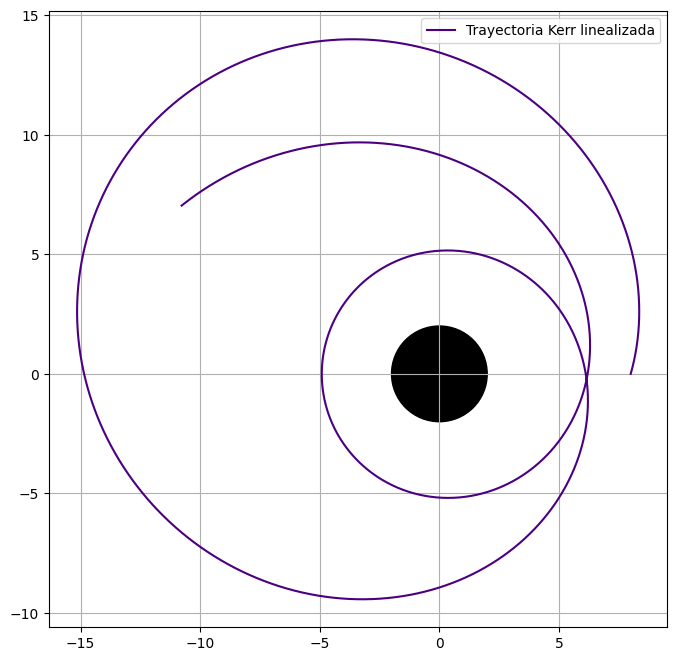

In [ ]:
# Graficando la trayectoria en el plano X,Y
xs = r_sol * np.cos(phi_sol)
ys = r_sol * np.sin(phi_sol)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)

ax.plot(xs, ys, color='indigo', label="Trayectoria Kerr linealizada")
ax.add_patch(Circle((0,0), radius=2*s, color='k'))

ax.set_aspect("equal")
ax.grid()
ax.legend()
plt.show()

Ahora calculando si las constantes de movimiento se mantienen constantes

In [ ]:
# Métrica de Kerr lineal en a
def metrica_lin(r, th, s, a, c):
    g = np.zeros((4,4))
    # Componentes de la métrica linealizada
    g[0,0] = (1 - 2*s/r) * c**2
    g[1,1] = -1/(1 - 2*s/r)
    g[2,2] = -r**2
    g[3,3] = -r**2 * np.sin(th)**2
    g[0,3] = g[3,0] = 2*a*c*s**2 * np.sin(th)**2 / r**2
    return g

# Definición de la norma en la métrica linealizada
def cons_norm(sol, s, a, c):
    norms = []
    for i in range(len(sol.t)):
        r  = sol.y[1,i]
        th = sol.y[2,i]
        U  = sol.y[4:8, i]
        g  = metrica_lin(r, th, s, a, c)
        norms.append(U @ g @ U)
    return np.array(norms)

# Verificando la conservación de energía
def cons_energia(sol, s, a, c):
    E_vals = []
    for i in range(len(sol.t)):
        r  = sol.y[1,i]
        th = sol.y[2,i]
        Ut, Ur, Uth, Uph = sol.y[4:8, i]
        g = metrica_lin(r, th, s, a, c)
        E = -(g[0,0]*Ut + g[0,3]*Uph)
        E_vals.append(E)
    return np.array(E_vals)


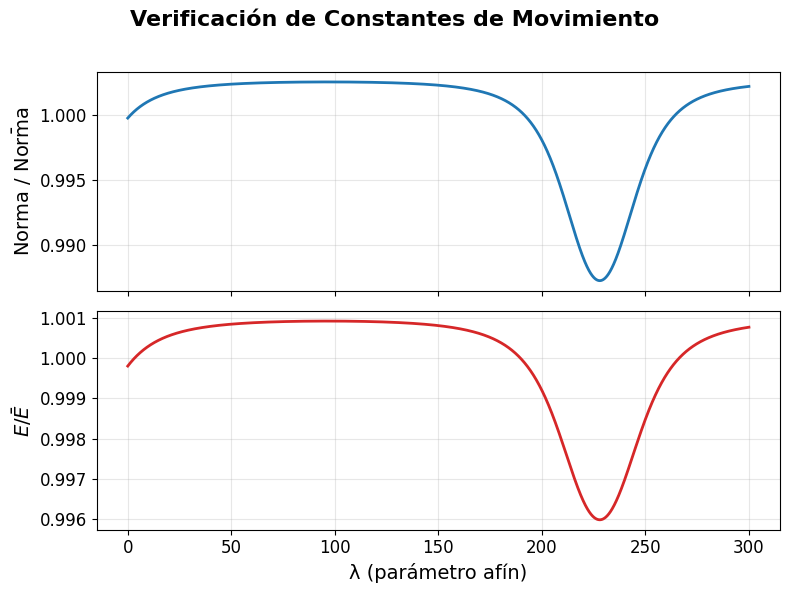

In [ ]:
# Evaluamos las funciones con los parámetros definidos
norms = cons_norm(sol, s, a_par, c)
Es    = cons_energia(sol, s, a_par, c)

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Colores agradables
color1 = "#1f77b4"   # azul
color2 = "#d62728"   # rojo

# --- Norma ---
axs[0].plot(sol.t, norms / norms.mean(), color=color1, lw=2)
axs[0].set_ylabel(r"Norma / $\bar{\text{Norma}}$", fontsize=14)
axs[0].grid(True, alpha=0.3)
axs[0].tick_params(axis='both', labelsize=12)

# --- Energía ---
axs[1].plot(sol.t, Es / Es.mean(), color=color2, lw=2)
axs[1].set_ylabel(r"$E / \bar{E}$", fontsize=14)
axs[1].set_xlabel("λ (parámetro afín)", fontsize=14)
axs[1].grid(True, alpha=0.3)
axs[1].tick_params(axis='both', labelsize=12)

# Título general
fig.suptitle("Verificación de Constantes de Movimiento",
             fontsize=16, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


A partir de las gráficas obtenidas, se observa que tanto la norma de la
cuadrivelocidad como la constante de energía $E$ permanecen prácticamente
constantes a lo largo de toda la integración. Las variaciones que se presentan
son del orden de $(10^{-3}),$
lo cual es esperable considerando que se está empleando la métrica de Kerr
linealizada en el parámetro de espín $a$.

Estas pequeñas desviaciones no representan una violación física de las
constantes de movimiento, sino que se deben a:

*  La aproximación lineal en $a$, que introduce errores de orden superior.
*  Errores numéricos asociados al método de integración y a la evolución en un intervalo grande del parámetro afín.


En conjunto, los resultados muestran que el integrador preserva correctamente
las cantidades conservadas dentro del marco de la aproximación linealizada,
confirmando la estabilidad y consistencia del cálculo.


### Gráfica en Plotly para diferentes condiciones iniciales







In [ ]:
# Transformación a cartesianas
def bl_to_cartesian(r, th, phi):
    x = r * np.sin(th) * np.cos(phi)
    y = r * np.sin(th) * np.sin(phi)
    z = r * np.cos(th)
    return x, y, z

# Integración de cada partícula
def integrar_particula(Y0, s, a_par, c=1.0, Tmax=200, N=4000):
    l_eval = np.linspace(0, Tmax, N)

    sol = solve_ivp(
        edm_kerr_lineal,
        [0, Tmax],
        Y0,
        t_eval=l_eval,
        args=(s, a_par, c),
        rtol=1e-11,
        atol=1e-11
    )

    return sol.y[1], sol.y[2], sol.y[3]   # r, theta, phi


In [ ]:
# CONDICIONES INICIALES PARA LAS 3 PARTÍCULAS
particulas = [
    {"r0": 8, "th0": np.pi/2 + 0.2, "phi0": 0.0,  "a": 0.1},
    {"r0": 10, "th0": np.pi/2 - 0.3, "phi0": 0.6, "a": 0.2},
    {"r0": 12, "th0": np.pi/2 + 0.5, "phi0": 1.5, "a": 0.25},
]

soluciones = []
colores = ["red", "blue", "green"]

for p in particulas:
    # Velocidades espaciales iniciales
    v = np.sqrt(1 / p["r0"])
    dr_dt  = 0.02
    dphi_dt = v / p["r0"]
    dth_dt  = 0.0

    # Métrica en el punto inicial
    gtt = (1 - 2*s/p["r0"])*c**2
    grr = -1/(1 - 2*s/p["r0"])
    gpp = -p["r0"]**2
    gtp = 2*p["a"]*c*s**2*np.sin(p["th0"])**2 / p["r0"]**2

    A = gtt
    B = 2*(grr*dr_dt**2 + gpp*dphi_dt**2 + gtp*dphi_dt)

    Ut = np.sqrt(1/(A+B))
    Ur = dr_dt * Ut
    Uphi = dphi_dt * Ut
    Uth = dth_dt * Ut

    Y0 = [0, p["r0"], p["th0"], p["phi0"], Ut, Ur, Uth, Uphi]

    r_sol, th_sol, phi_sol = integrar_particula(Y0, s, p["a"])
    soluciones.append((r_sol, th_sol, phi_sol))

In [ ]:
# CONSTRUCCIÓN DE LA FIGURA EN PLOTLY
fig = go.Figure()

# Trayectorias
for (r, th, phi), color in zip(soluciones, colores):
    x, y, z = bl_to_cartesian(r, th, phi)
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode="lines",
        line=dict(color=color, width=4),
        name=f"Trayectoria {color}"
    ))

# Esfera del agujero negro (horizonte)
RH = 2*s
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 50)

xH = RH * np.outer(np.cos(u), np.sin(v))
yH = RH * np.outer(np.sin(u), np.sin(v))
zH = RH * np.outer(np.ones_like(u), np.cos(v))

fig.add_trace(go.Surface(
    x=xH, y=yH, z=zH,
    colorscale="gray",
    opacity=0.5,
    showscale=False,
    name="Horizonte"
))

# Layout
fig.update_layout(
    title="Órbitas geodésicas en Kerr linealizado (Plotly 3D)",
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="z",
        aspectmode="data"
    ),
    width=900,
    height=800
)

fig.show()

**Nota:** *Jugando un poco con las condiciones iniciales se puede observar que hay valores de $r$ y de $a$ que hacen que la partícula caiga dentro del agujero y se empiecen a producir errores numéricos, en especial con radios pequeños o valores negativos de a $(a<0)$*

In [ ]:
# Coordenadas de Boyer–Lindquist
t, r, theta, phi = sp.symbols('t r theta phi', real=True)

# Parámetros físicos:
s, a, c = sp.symbols('s a c', real=True)

# Cantidades auxiliares
Sigma = r**2 + (a*s)**2 * sp.cos(theta)**2
Delta = r**2 - 2*s*r + (a*s)**2

# Construcción de la métrica de Kerr en coordenadas Boyer–Lindquist
g = sp.zeros(4)

# g_tt
g[0, 0] = (1 - 2*s*r / Sigma) * c**2

# g_tφ = g_φt
g_tphi = (2 * a * c * s**2 * r * sp.sin(theta)**2) / Sigma
g[0, 3] = g_tphi
g[3, 0] = g_tphi

# g_rr
g[1, 1] = -Sigma / Delta

# g_θθ
g[2, 2] = -Sigma

# g_φφ
g[3, 3] = - (sp.sin(theta)**2 / Sigma) * (
    (r**2 + (a*s)**2)**2 - (a*s)**2 * Delta * sp.sin(theta)**2
)
# Calculando los simbolos de Christoffel simbolicamente
metrica = es.MetricTensor(sp.Array(g), [t, r, theta, phi])
G = es.ChristoffelSymbols.from_metric(metrica)

coords = ['t','r','θ','φ']
Gamma = G.tensor()


In [ ]:
# Sacando las funciones numéricas de los símbolos
G_f = [[[None]*4 for _ in range(4)] for __ in range(4)]

for mu in range(4):
    for a1 in range(4):
        for a2 in range(4):
            G_f[mu][a1][a2] = sp.lambdify(
                (r, theta, s, a, c),
                sp.simplify(Gamma[mu, a1, a2]),
                "numpy"
            )

In [ ]:
def edm_kerr(l, Y, s, a, c=1.0):

    t, r, th, phi = Y[0:4]
    Ut, Ur, Uth, Uph = Y[4:8]

    dY = np.zeros(8)

    dY[0:4] = [Ut, Ur, Uth, Uph]

    for mu in range(4):
        acc = 0
        for a1 in range(4):
            for a2 in range(4):
                acc += G_f[mu][a1][a2](r, th, s, a, c) * Y[4+a1] * Y[4+a2]
        dY[4+mu] = -acc

    return dY

In [ ]:
# Integración de la ecuacion de movimiento
def integrar_kerr(Y0, s, a_par, c=1, Tmax=200, N=5000):
    l_eval = np.linspace(0, Tmax, N)

    sol = solve_ivp(
        edm_kerr, [0, Tmax], Y0,
        args=(s, a_par, c),
        t_eval=l_eval,
        atol=1e-10, rtol=1e-10
    )

    return sol.y

In [ ]:
# Condiciones iniciales
particulas = [
    {"r0": 15, "th0": np.pi/2 - 0.7, "phi0": 0.8,  "a": 0.9},#red
    {"r0": 10, "th0": np.pi/2 - 0.3, "phi0": 0.6, "a": 0.5}, #blue
    {"r0": 13, "th0": np.pi/2 + 0.5, "phi0": 1.5, "a": -0.5},#green
]

soluciones_f = []

for p in particulas:
    r0   = p["r0"]
    th0  = p["th0"]
    phi0 = p["phi0"]
    a0   = p["a"]
    s0   = 1
    c0   = 1

    #   Velocidades iniciales
    v = np.sqrt(1 / r0)
    dr_dt   = 0.01
    dphi_dt = v / r0
    dth_dt  = 0.0

    #  Cantidades auxiliares de Kerr
    Sigma = r0**2 + (a0*s0)**2 * np.cos(th0)**2
    Delta = r0**2 - 2*s0*r0 + (a0*s0)**2

    #   Componentes métricos de Kerr
    gtt = (1 - 2*s0*r0/Sigma) * c0**2
    gtphi = (2 * a0 * c0 * s0**2 * r0 * np.sin(th0)**2) / Sigma
    grr = -Sigma / Delta
    gthth = -Sigma
    gphph = -(np.sin(th0)**2 / Sigma) * (
        (r0**2 + (a0*s0)**2)**2 - (a0*s0)**2 * Delta * np.sin(th0)**2
    )

    #   Normalización g_{μν}U^μU^ν = 1
    A = (
        gtt
        + 2 * gtphi * dphi_dt
        + gphph * dphi_dt**2
        + grr   * dr_dt**2
        + gthth * dth_dt**2
    )

    Ut   = np.sqrt(1 / A)
    Ur   = dr_dt   * Ut
    Uth  = dth_dt  * Ut
    Uphi = dphi_dt * Ut

    #   Estado inicial
    Y0 = [0, r0, th0, phi0, Ut, Ur, Uth, Uphi]

    sol_f = integrar_kerr(Y0, s=s0, a_par=a0)
    soluciones_f.append(sol_f)

In [ ]:
fig = go.Figure()

for sol_f, color in zip(soluciones_f, colores):
    r, th, phi = sol_f[1], sol_f[2], sol_f[3]
    x, y, z = bl_to_cartesian(r, th, phi)

    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode="lines",
        line=dict(color=color, width=4),
        name=f"Trayectoria {color}"
    ))

# Horizonte
RH = 2
u = np.linspace(0,2*np.pi,50)
v = np.linspace(0,np.pi,50)

xH = RH * np.outer(np.cos(u), np.sin(v))
yH = RH * np.outer(np.sin(u), np.sin(v))
zH = RH * np.outer(np.ones_like(u), np.cos(v))

fig.add_trace(go.Surface(
    x=xH, y=yH, z=zH,
    colorscale="gray",
    opacity=0.5,
    showscale=False
))

fig.update_layout(
    title="Órbitas geodésicas en Kerr",
    width=900, height=800,
    scene=dict(aspectmode="data")
)

fig.show()


## Conclusiones

El parámetro adimensional de spin
$
a \equiv \frac{cJ}{GM^{2}},
$
controla el efecto de arrastre de marco en la métrica de Kerr y determina en gran medida la dinámica orbital de las partículas de prueba.

Los resultados numéricos muestran varios comportamientos característicos:

**Dependencia con el signo de $a$.**  
   Para órbitas con condiciones iniciales similares, los casos *prógrados* ($a>0$) tienden a resistir mejor la captura, mientras que para órbitas *retrógradas* ($a<0$)  el arrastre de marco actúa en contra del movimiento de la partícula, disminuyendo su soporte centrífugo y facilitando la caída hacia el agujero negro.

 **Dependencia con el radio inicial $r_0$.**  
   Radios pequeños reducen drásticamente la posibilidad de órbitas estables: si $r_0$ es demasiado bajo, incluso pequeñas perturbaciones radiales pueden eliminar los puntos de retorno y provocar una espiralización hacia el horizonte.

**Dependencia con la latitud $\theta$ (cercanía a los polos).**  
   Partículas que inician cerca de los polos ($\theta \approx 0$ o $\theta \approx \pi$) carecen del momento angular azimutal suficiente y suelen caer casi en línea recta hacia el agujero negro. Este efecto se vuelve más fuerte para valores negativos de $a$.

**Excentricidad inicial y estabilidad.**  
   Un pequeño empujón radial ($\dot r\neq 0$) genera órbitas elípticas, pero una excentricidad excesiva destruye la estabilidad.

**Consideraciones numéricas.**  
   Las trayectorias que cruzan el horizonte pueden producir errores numéricos debido a singularidades coordinadas en Boyer–Lindquist. Esto ocurre con mayor frecuencia cuando:
   - $a<0$,
   - $r_0$ es pequeño,
   - la partícula inicia cerca de los polos.

